# Autoencoders

### 1. ORIGINAL (propuesto por Vanessa)

Epoch 1/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2332 - val_loss: 0.1537
Epoch 2/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1373 - val_loss: 0.1226
Epoch 3/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1176 - val_loss: 0.1116
Epoch 4/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1100 - val_loss: 0.1069
Epoch 5/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1054 - val_loss: 0.1022
Epoch 6/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1023 - val_loss: 0.0999
Epoch 7/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1004 - val_loss: 0.0983
Epoch 8/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0987 - val_loss: 0.0969
Epoch 9/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0971 - val_loss: 0.0953
Epoch 10/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0959 - val_loss: 0.0946
Epoch 11/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0950 - val_loss: 0.0935
Epoch 12/15
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

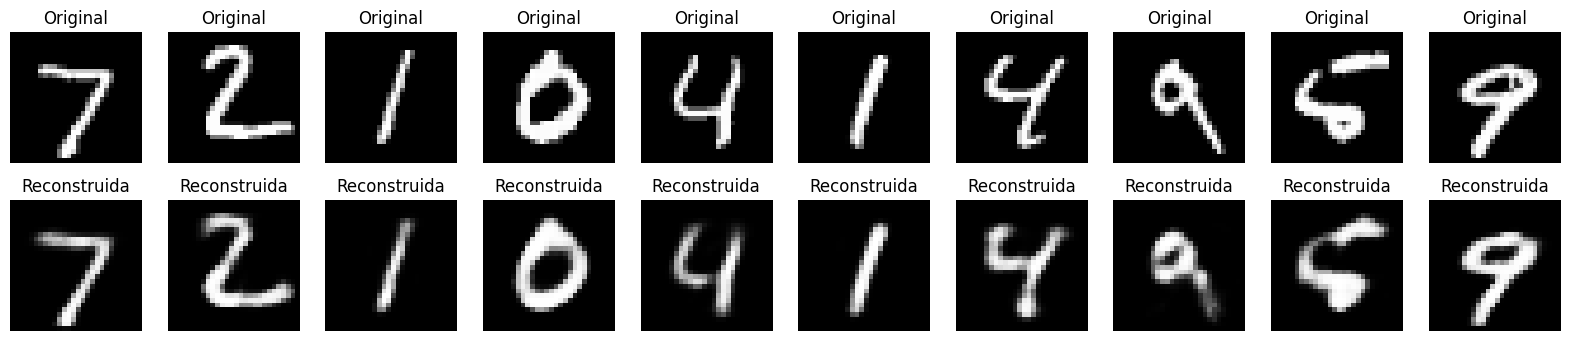

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt


# Cargar MNIST
(X_train, _), (X_test, _) = tf.keras.datasets.mnist.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Aplanar (784)
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)


# Definir Autoencoder

encoding_dim = 32  # compresión fuerte

input_img = tf.keras.Input(shape=(784,))

# Encoder
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(encoding_dim, activation='relu')(encoded)

# Decoder
decoded = layers.Dense(128, activation='relu')(encoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenamiento

autoencoder.fit(
    X_train,
    X_train,   # <- importante: entrada = salida
    epochs=15,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# Reconstrucción

decoded_imgs = autoencoder.predict(X_test[:10])

# Visualización

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstruida
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Reconstruida")
    plt.axis('off')

plt.show()

#### 1.2. Dataset = CIFAR-10

##### 1.2.1.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Input correcto
input_img = tf.keras.Input(shape=(32,32,3))

# Encoder
x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2,2), padding='same')(x)

x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2,2), padding='same')(x)

encoded = layers.Conv2D(128,(3,3), activation='relu', padding='same')(x)

# Decoder
x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)

x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento
autoencoder.fit(
    X_train, X_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# Predicción
decoded_imgs = autoencoder.predict(X_test[:5])

Epoch 1/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 18s 87ms/step - loss: 0.0922 - val_loss: 0.0609
Epoch 2/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0572 - val_loss: 0.0517
Epoch 3/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - loss: 0.0510 - val_loss: 0.0491
Epoch 4/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - loss: 0.0480 - val_loss: 0.0457
Epoch 5/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step - loss: 0.0458 - val_loss: 0.0467
Epoch 6/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 84ms/step - loss: 0.0445 - val_loss: 0.0429
Epoch 7/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - loss: 0.0434 - val_loss: 0.0422
Epoch 8/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - loss: 0.0425 - val_loss: 0.0433
Epoch 9/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 16s 83ms/step - loss: 0.0416 - val_loss: 0.0427
Epoch 10/10
196/196 ━━━━━━━━━━━━━━━━━━━━ 17s 85ms/step - loss: 0.0410 - val_loss: 0.0396
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


#### 1.2.2. 3 layers

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Input correcto
input_img = tf.keras.Input(shape=(32,32,3))

# Encoder
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

e3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(ep2)
e3 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(e3)
ep3 = layers.MaxPooling2D((2,2), padding='same')(e3)

# Bottleneck
bn = layers.Conv2D(256,(3,3), activation='relu', padding='same')(ep3)
bn = layers.Conv2D(256,(3,3), activation='relu', padding='same')(bn)

# Decoder
d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Concatenate()([d1, e3])
d1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(128, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Concatenate()([d2, e2])
d2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(64, (3,3), activation='relu', padding='same')(d2)

d3 = layers.UpSampling2D((2,2))(d2)
d3 = layers.Concatenate()([d3, e1])
d3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d3)
d3 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d3)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d3)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento
autoencoder.fit(
    X_train, X_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# Predicción
decoded_imgs = autoencoder.predict(X_test[:5])

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 114s 286ms/step - loss: 0.0470 - val_loss: 0.0188
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 102s 260ms/step - loss: 0.0174 - val_loss: 0.0146
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 98s 251ms/step - loss: 0.0139 - val_loss: 0.0154
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 98s 251ms/step - loss: 0.0120 - val_loss: 0.0106
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 98s 251ms/step - loss: 0.0110 - val_loss: 0.0093
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


##### 1.2.3: 2 layers, smaller

In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Cargar CIFAR-10
(X_train, _), (X_test, _) = tf.keras.datasets.cifar10.load_data()

# Normalizar
X_train = X_train / 255.0
X_test = X_test / 255.0

# Input correcto
input_img = tf.keras.Input(shape=(32,32,3))

# Encoder
e1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(input_img)
e1 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(e1)
ep1 = layers.MaxPooling2D((2,2), padding='same')(e1)

e2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(ep1)
e2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(e2)
ep2 = layers.MaxPooling2D((2,2), padding='same')(e2)

# Bottleneck
bn = layers.Conv2D(64,(3,3), activation='relu', padding='same')(ep2)
bn = layers.Conv2D(64,(3,3), activation='relu', padding='same')(bn)

# Decoder

d1 = layers.UpSampling2D((2,2))(bn)
d1 = layers.Concatenate()([d1, e2])
d1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d1)
d1 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(d1)

d2 = layers.UpSampling2D((2,2))(d1)
d2 = layers.Concatenate()([d2, e1])
d2 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(d2)
d2 = layers.Conv2D(16, (3,3), activation='relu', padding='same')(d2)

decoded = layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(d2)

# Modelo
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mae')

# Entrenamiento
autoencoder.fit(
    X_train, X_train,
    epochs=5,
    batch_size=128,
    shuffle=True,
    validation_data=(X_test, X_test)
)

# Predicción
decoded_imgs = autoencoder.predict(X_test[:5])

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 67ms/step - loss: 0.0561 - val_loss: 0.0287
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - loss: 0.0233 - val_loss: 0.0211
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 24s 62ms/step - loss: 0.0184 - val_loss: 0.0168
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - loss: 0.0160 - val_loss: 0.0155
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - loss: 0.0146 - val_loss: 0.0142
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step


#### VISUALIZAR

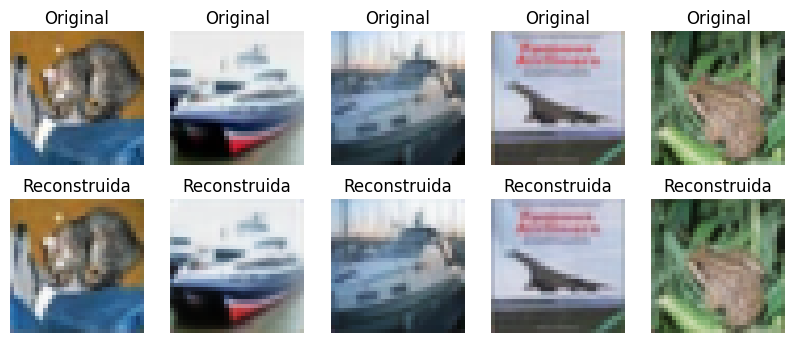

In [6]:
# Visualización
n = 5
plt.figure(figsize=(10,4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i+1)
    plt.imshow(X_test[i])
    plt.title("Original")
    plt.axis('off')

    # Reconstruida
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i])
    plt.title("Reconstruida")
    plt.axis('off')

plt.show()

### 2. Pruebas con Dataset RealWaste

#### 2.1. Propio

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

layers = tf.keras.layers
models = tf.keras.models
utils = tf.keras.utils

directory = 'datasets/realwaste-main/RealWaste/'

# Dataset
train_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="training",
    batch_size=32,
    image_size=(64,64),
    shuffle=True,
    seed=12,
)

val_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="validation",
    batch_size=32,
    image_size=(64,64),
    shuffle=True,
    seed=12,
)

encoding_dim = 32

def preprocess(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, x 

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)


input_img = tf.keras.Input(shape=(64,64,3))

# Encoder
x = layers.Flatten()(input_img)
x = layers.Dense(3072, activation='relu')(x)
x = layers.Dense(768, activation='relu')(x)
encoded = layers.Dense(encoding_dim, activation='relu')(x)

# Decoder
x = layers.Dense(768, activation='relu')(encoded)
x = layers.Dense(3072, activation='relu')(x)
x = layers.Dense(64*64*3, activation='sigmoid')(x)
decoded = layers.Reshape((64,64,3))(x)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entrenamiento
autoencoder.fit(
    train_dataset,
    epochs=3,
    validation_data=val_dataset
)

# Reconstrucción
for batch in val_dataset.take(1):
    imgs, _ = batch
    decoded_imgs = autoencoder.predict(imgs[:10])

    n = 10
    plt.figure(figsize=(20, 4))

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(imgs[i])
        plt.title("Original")
        plt.axis('off')

        # Reconstruida
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.title("Reconstruida")
        plt.axis('off')

    plt.show()

Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Epoch 1/3
 14/119 ━━━━━━━━━━━━━━━━━━━━ 48s 459ms/step - loss: 0.0400

KeyboardInterrupt: 

#### 2.1. Convolutional Autoencoder

Found 4752 files belonging to 9 classes.
Using 3802 files for training.
Found 4752 files belonging to 9 classes.
Using 950 files for validation.
Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 264ms/step - loss: 0.0207 - val_loss: 0.0106
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 32s 264ms/step - loss: 0.0093 - val_loss: 0.0082
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 32s 263ms/step - loss: 0.0071 - val_loss: 0.0063
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 31s 263ms/step - loss: 0.0062 - val_loss: 0.0059
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 31s 263ms/step - loss: 0.0060 - val_loss: 0.0057
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 32s 266ms/step - loss: 0.0059 - val_loss: 0.0056
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 31s 263ms/step - loss: 0.0057 - val_loss: 0.0055
Epoch 8/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 32s 266ms/step - loss: 0.0055 - val_loss: 0.0053
Epoch 9/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 273ms/step - loss: 0.0055 - val_loss: 0.0052
Epoch 10/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 33s 272ms/ste

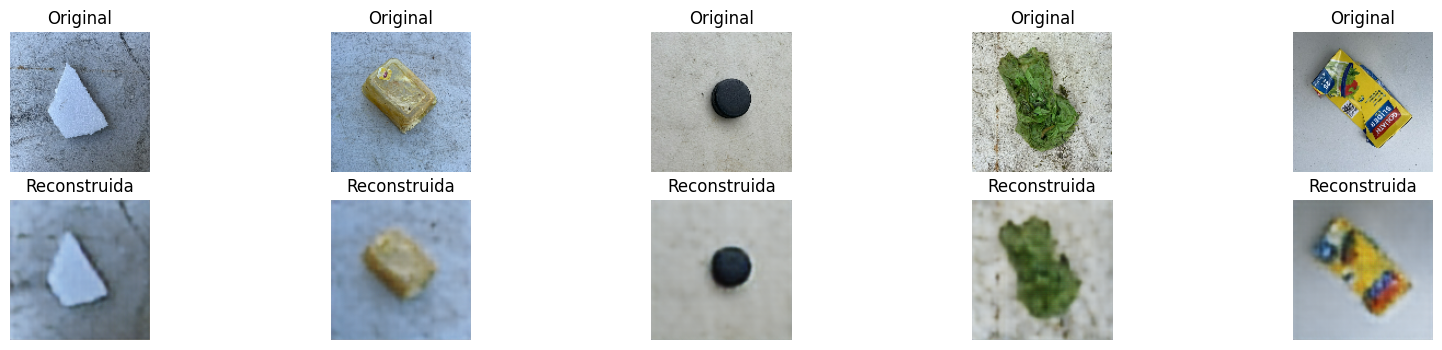

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

layers = tf.keras.layers
models = tf.keras.models
utils = tf.keras.utils

directory = 'datasets/realwaste-main/RealWaste/'

# Dataset
train_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="training",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=12,
)

val_dataset = utils.image_dataset_from_directory(
    directory,
    validation_split=0.2,
    subset="validation",
    batch_size=32,
    image_size=(128,128),
    shuffle=True,
    seed=12,
)

def preprocess(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, x 

train_dataset = train_dataset.map(preprocess)
val_dataset = val_dataset.map(preprocess)


input_img = layers.Input(shape=(128,128,3))

# Encoder
x = layers.Conv2D(32, 3, activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
x = layers.MaxPooling2D(2, padding='same')(x)

x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D(2, padding='same')(x)

# Decoder
x = layers.Conv2DTranspose(128, 3, strides=2, activation='relu', padding='same')(encoded)
x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)
x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)

decoded = layers.Conv2D(3, 3, activation='sigmoid', padding='same')(x)

autoencoder = models.Model(input_img, decoded)

autoencoder.compile(optimizer='adam', loss='mse')

# Entrenamiento
autoencoder.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


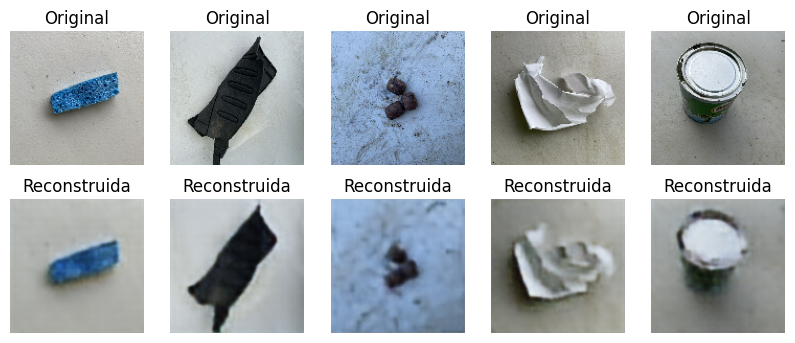

In [18]:
# Reconstrucción
for batch in val_dataset.take(1):
    imgs, _ = batch
    decoded_imgs = autoencoder.predict(imgs[:5])

    n = 5
    plt.figure(figsize=(10, 4))

    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(imgs[i])
        plt.title("Original")
        plt.axis('off')

        # Reconstruida
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i])
        plt.title("Reconstruida")
        plt.axis('off')

    plt.show()